# What Really Drives Developer Salaries? Insights from the 2024 StackOverflow Developer Survey

**Author:** Sukh Sandhu — Udacity Data Scientist Nanodegree, Project 1 (*Write a Data Science Blog Post*)

This notebook is organised as a readable report following the six stages of the **CRISP-DM** process:

1. **Business Understanding** — the questions we want to answer
2. **Data Understanding** — what the survey data contains, including missing values
3. **Data Preparation** — filtering, cleaning, imputation and encoding (every choice documented)
4. **Modeling** — a Random Forest regression that predicts salary
5. **Evaluation** — held-out metrics, feature importances and limitations
6. **Deployment** — communicating results in a blog post and README

## The dataset

We use the official **2024 StackOverflow Annual Developer Survey** — 65,437 responses and 114 columns, collected from developers in 185+ countries.

> **Getting the data:** the CSV (~150 MB) is not committed to this repository because of its size. Download it from <https://survey.stackoverflow.co/> (2024 → *Data (CSV)*) and save it next to this notebook as `so_survey_results_2024.csv`.

## CRISP-DM Stage 1 — Business Understanding

Developer pay is opaque: job ads hide ranges, and anecdotes dominate. Using real survey data we ask five concrete questions:

* **Q1.** Which programming languages are associated with the highest salaries?
* **Q2.** How do professional experience and education relate to compensation?
* **Q3.** How does remote, hybrid or in-person work relate to job satisfaction?
* **Q4.** How does compensation vary across countries?
* **Q5.** Can a model predict a developer's salary from their profile — and which factors matter most?

These map to decisions real stakeholders face: which skills to learn (Q1–Q2), what work arrangement to negotiate (Q3), where to hire or relocate (Q4), and how to benchmark an offer (Q5).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

%matplotlib inline


# --------------------------------------------------------------------------
# Configuration constants
# --------------------------------------------------------------------------
DEFAULT_DATA_PATH = "so_survey_results_2024.csv"
RANDOM_STATE = 42

# Documented salary bounds: values below 5k USD are almost always currency
# conversion artefacts or part-time pay reported as yearly; values above
# 400k USD (the 99th percentile) are extreme outliers that would dominate
# squared-error metrics.
SALARY_MIN_USD = 5_000
SALARY_MAX_USD = 400_000

MISSING_CATEGORY_LABEL = "Not specified"

# Explicit category orders for genuinely ORDINAL variables. Encoding these
# with ordered integers preserves their natural ranking.
EDUCATION_ORDER = [
    "Primary/elementary school",
    "Secondary school (e.g. American high school, German Realschule or "
    "Gymnasium, etc.)",
    "Some college/university study without earning a degree",
    "Associate degree (A.A., A.S., etc.)",
    "Bachelor’s degree (B.A., B.S., B.Eng., etc.)",
    "Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",
    "Professional degree (JD, MD, Ph.D, Ed.D, etc.)",
    "Something else",
]
ORG_SIZE_ORDER = [
    "Just me - I am a freelancer, sole proprietor, etc.",
    "2 to 9 employees",
    "10 to 19 employees",
    "20 to 99 employees",
    "100 to 499 employees",
    "500 to 999 employees",
    "1,000 to 4,999 employees",
    "5,000 to 9,999 employees",
    "10,000 or more employees",
    "I don’t know",
]
AGE_ORDER = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older",
    "Prefer not to say",
]

ORDINAL_FEATURES = {
    "EdLevel": EDUCATION_ORDER,
    "OrgSize": ORG_SIZE_ORDER,
    "Age": AGE_ORDER,
}
# Nominal (unordered) variables: one-hot encoded because assigning them
# ordered integers would invent a ranking that does not exist.
NOMINAL_FEATURES = ["Country", "DevType", "RemoteWork"]
NUMERIC_FEATURES = ["YearsCodeProNumeric"]
MAX_ONE_HOT_CATEGORIES = 12

BUSINESS_QUESTIONS = [
    "Q1. Which programming languages are associated with the highest "
    "salaries?",
    "Q2. How do professional experience and education relate to "
    "compensation?",
    "Q3. How does remote, hybrid or in-person work relate to job "
    "satisfaction?",
    "Q4. How does compensation vary across countries?",
    "Q5. Can a model predict a developer's salary, and which factors "
    "matter most?",
]

DATA_PATH = "so_survey_results_2024.csv"

## CRISP-DM Stage 2 — Data Understanding

We first load the raw survey and profile the columns used in this analysis. Two helper functions keep this reusable: one loads the CSV with a clear error if it is absent, the other summarises missing values.

A key observation drives the whole preparation strategy: **most columns have substantial missing data.** Compensation (`ConvertedCompYearly`) is missing for ~64% of respondents (many participants skip pay questions), and job satisfaction (`JobSat`) for ~56%. This is normal for voluntary surveys — the preparation stage below documents exactly how each gap is handled.

In [2]:
def load_survey_data(csv_path):
    """Load the raw StackOverflow survey CSV.

    Parameters
    ----------
    csv_path : str
        Path to the official 2024 `results.csv` download.

    Returns
    -------
    pandas.DataFrame
        Raw survey responses (one row per respondent).
    """
    try:
        return pd.read_csv(csv_path, low_memory=False)
    except FileNotFoundError:
        raise SystemExit(
            f"Data file not found: {csv_path}\n"
            "Download the 2024 survey CSV from https://survey.stackoverflow.co/ "
            "and save it as so_survey_results_2024.csv (see README)."
        )


def summarize_missing_values(survey_df, columns):
    """Return a count and percentage of missing values per column.

    Parameters
    ----------
    survey_df : pandas.DataFrame
        Survey data to profile.
    columns : list of str
        Columns to include in the summary.

    Returns
    -------
    pandas.DataFrame
        Indexed by column name with `missing_count` and `missing_pct`.
    """
    missing_count = survey_df[columns].isnull().sum()
    missing_pct = (missing_count / len(survey_df) * 100).round(1)
    return pd.DataFrame(
        {"missing_count": missing_count, "missing_pct": missing_pct}
    ).sort_values("missing_pct", ascending=False)

In [3]:
raw_survey_df = load_survey_data(DATA_PATH)
print(f"Survey shape: {raw_survey_df.shape[0]:,} respondents x "
      f"{raw_survey_df.shape[1]} columns")

key_columns = [
    "ConvertedCompYearly", "JobSat", "YearsCodePro", "EdLevel", "Country",
    "DevType", "OrgSize", "RemoteWork", "LanguageHaveWorkedWith",
]
summarize_missing_values(raw_survey_df, key_columns)

Survey shape: 65,437 respondents x 114 columns


,missing_count,missing_pct
ConvertedCompYearly,42002,64.2
JobSat,36311,55.5
OrgSize,17957,27.4
YearsCodePro,13827,21.1
RemoteWork,10631,16.2
Country,6507,9.9
DevType,5992,9.2
LanguageHaveWorkedWith,5692,8.7
EdLevel,4653,7.1


## CRISP-DM Stage 3 — Data Preparation

### Filtering decisions

* Keep only **professional developers** (`MainBranch == "I am a developer by profession"`) who are **employed full-time** — students, hobbyists and part-timers answer pay questions on a different basis, which would distort comparisons.
* Keep only rows where the **target variable** `ConvertedCompYearly` is present. Rows without the target are *dropped, not imputed*: inventing the value we are trying to study would fabricate signal and leak noise into both the descriptive answers and the model.
* Keep salaries between **\$5,000 and \$400,000** (the 99th percentile). Values below the floor are almost always currency-conversion artefacts or partial-year pay; values above the cap are extreme outliers that would dominate squared-error metrics.

### Missing-value strategy for the remaining feature columns

| Feature type | Columns | Strategy | Why |
|---|---|---|---|
| Nominal categorical | `Country`, `DevType`, `RemoteWork` | Fill with explicit `"Not specified"` category | "Did not answer" is itself informative; keeps rows usable without inventing a country or role |
| Ordinal categorical | `EdLevel`, `OrgSize`, `Age` | Encoded to `-1` by the `OrdinalEncoder` | Keeps one ordered scale with "unknown" below the lowest real level |
| Numeric | `YearsCodePro` | Median imputation | Median is robust to the long right tail of experience |

`YearsCodePro` also needs cleaning before it can be numeric: the survey stores `"Less than 1 year"` and `"More than 50 years"` as text, mapped here to 0.5 and 51.

In [4]:
def clean_years_experience(years_series):
    """Convert the `YearsCodePro` survey column to numeric years.

    The survey stores the answer as text with two special values:
    "Less than 1 year" (mapped to 0.5) and "More than 50 years"
    (mapped to 51). Everything else parses directly as a number.

    Parameters
    ----------
    years_series : pandas.Series
        Raw `YearsCodePro` column.

    Returns
    -------
    pandas.Series
        Numeric years of professional coding experience (NaN preserved).
    """
    text_value_map = {"Less than 1 year": 0.5, "More than 50 years": 51.0}
    return pd.to_numeric(years_series.replace(text_value_map), errors="coerce")


def filter_professional_developers(raw_df):
    """Restrict the survey to comparable, professionally paid respondents.

    Filtering decisions (documented for CRISP-DM Data Preparation):
    * `MainBranch` == "I am a developer by profession" - hobbyists and
      students answer very different pay questions.
    * `Employment` contains "Employed, full-time" - keeps yearly salaries
      comparable across respondents.
    * `ConvertedCompYearly` is present - rows without the target variable
      cannot be used for salary analysis or supervised modeling, so they
      are dropped rather than imputed (imputing a target would fabricate
      the very signal we are trying to study).
    * Salary kept within [SALARY_MIN_USD, SALARY_MAX_USD] to remove
      currency artefacts and extreme outliers.

    Parameters
    ----------
    raw_df : pandas.DataFrame
        Raw survey responses.

    Returns
    -------
    pandas.DataFrame
        Filtered copy with an added numeric `YearsCodeProNumeric` column.
    """
    is_professional = raw_df["MainBranch"] == "I am a developer by profession"
    is_full_time = raw_df["Employment"].str.contains(
        "Employed, full-time", na=False
    )
    has_salary = raw_df["ConvertedCompYearly"].notna()

    developers_df = raw_df[is_professional & is_full_time & has_salary].copy()
    salary_in_range = developers_df["ConvertedCompYearly"].between(
        SALARY_MIN_USD, SALARY_MAX_USD
    )
    developers_df = developers_df[salary_in_range]
    developers_df["YearsCodeProNumeric"] = clean_years_experience(
        developers_df["YearsCodePro"]
    )
    return developers_df


def impute_missing_features(developers_df):
    """Handle missing values in the modeling features.

    Strategy (and the reasoning behind it):
    * Nominal categoricals (Country, DevType, RemoteWork) - missing answers
      are replaced with an explicit "Not specified" category. "Did not
      answer" is itself informative, and this keeps every row usable
      without inventing a country or role.
    * Ordinal categoricals (EdLevel, OrgSize, Age) - left as NaN here and
      encoded to -1 by the OrdinalEncoder (`encoded_missing_value=-1`),
      which keeps them in a single ordered scale with "unknown" below the
      lowest real level.
    * Numeric YearsCodeProNumeric - imputed with the median, which is
      robust to the long right tail of the experience distribution.

    Parameters
    ----------
    developers_df : pandas.DataFrame
        Output of :func:`filter_professional_developers`.

    Returns
    -------
    pandas.DataFrame
        Copy with imputations applied.
    """
    imputed_df = developers_df.copy()
    for column in NOMINAL_FEATURES:
        imputed_df[column] = imputed_df[column].fillna(MISSING_CATEGORY_LABEL)
    median_years = imputed_df["YearsCodeProNumeric"].median()
    imputed_df["YearsCodeProNumeric"] = imputed_df[
        "YearsCodeProNumeric"
    ].fillna(median_years)
    return imputed_df

In [5]:
developers_df = filter_professional_developers(raw_survey_df)
retained_pct = len(developers_df) / len(raw_survey_df) * 100
print(f"Professional full-time developers with valid salary: "
      f"{len(developers_df):,} of {len(raw_survey_df):,} respondents "
      f"({retained_pct:.1f}%)")

developers_df = impute_missing_features(developers_df)
modeling_columns = list(ORDINAL_FEATURES) + NOMINAL_FEATURES + NUMERIC_FEATURES
print("\nMissing values remaining in nominal/numeric model features:")
print(developers_df[NOMINAL_FEATURES + NUMERIC_FEATURES].isnull().sum().to_string())
print("\n(Ordinal features keep NaN on purpose - the encoder maps them to -1:)")
print(developers_df[list(ORDINAL_FEATURES)].isnull().sum().to_string())

Professional full-time developers with valid salary: 17,543 of 65,437 respondents (26.8%)

Missing values remaining in nominal/numeric model features:
Country                0
DevType                0
RemoteWork             0
YearsCodeProNumeric    0

(Ordinal features keep NaN on purpose - the encoder maps them to -1:)
EdLevel     0
OrgSize    16
Age         0


## CRISP-DM Stage 4 — Analysis & Modeling

### Q1. Which programming languages are associated with the highest salaries?

`LanguageHaveWorkedWith` is a semicolon-separated multi-select, so it is split and exploded to one row per developer–language pair. Only languages with at least 1,000 professional users are kept so the medians stay statistically meaningful.

In [6]:
def median_salary_by_language(developers_df, min_respondents=1_000):
    """Median salary for each programming language worked with.

    `LanguageHaveWorkedWith` is a semicolon-separated multi-select, so the
    column is split and exploded to one row per developer-language pair.

    Parameters
    ----------
    developers_df : pandas.DataFrame
        Filtered developer rows.
    min_respondents : int, optional
        Languages with fewer users than this are dropped so medians stay
        statistically meaningful.

    Returns
    -------
    pandas.Series
        Median salary (USD) indexed by language, highest first.
    """
    language_salary_df = developers_df[
        ["LanguageHaveWorkedWith", "ConvertedCompYearly"]
    ].dropna()
    language_salary_df = language_salary_df.assign(
        Language=language_salary_df["LanguageHaveWorkedWith"].str.split(";")
    ).explode("Language")

    language_counts = language_salary_df["Language"].value_counts()
    popular_languages = language_counts[
        language_counts >= min_respondents
    ].index
    popular_df = language_salary_df[
        language_salary_df["Language"].isin(popular_languages)
    ]
    return (
        popular_df.groupby("Language")["ConvertedCompYearly"]
        .median()
        .sort_values(ascending=False)
    )

In [7]:
language_salaries = median_salary_by_language(developers_df)
top_language_salaries = (language_salaries.head(10) / 1_000).round(1)
top_language_salaries.rename("Median salary (USD thousands)").to_frame()

,Median salary (USD thousands)
Language,
Ruby,95.0
Rust,83.7
Go,82.8
Bash/Shell (all shells),80.6
PowerShell,76.3
Python,75.0
Kotlin,72.5
TypeScript,72.5
C++,71.8


**Answer (Q1):** Niche-but-loved languages pay best. **Ruby (~\$95k)**, **Rust (~\$84k)** and **Go (~\$83k)** top the medians, with shell scripting close behind — a premium for specialised infrastructure and systems skills. Python sits mid-pack (~\$75k) precisely because it is ubiquitous: enormous supply keeps the median moderate. *Correlation caveat:* language users differ in seniority and geography, so these are associations, not causal effects of learning a language.

### Q2. How do professional experience and education relate to compensation?

We measure the linear association between cleaned years of professional coding and salary, and compare median salary across education levels using one reusable group-by helper (also reused for Q4 — DRY).

In [8]:
def experience_salary_correlation(developers_df):
    """Pearson correlation between professional experience and salary.

    Parameters
    ----------
    developers_df : pandas.DataFrame
        Filtered developer rows with `YearsCodeProNumeric`.

    Returns
    -------
    float
        Correlation coefficient (NaN rows excluded pairwise).
    """
    return developers_df["YearsCodeProNumeric"].corr(
        developers_df["ConvertedCompYearly"]
    )


def median_salary_by_group(developers_df, group_column, min_respondents=1):
    """Median salary by an arbitrary categorical column.

    Reused for education (Q2) and country (Q4) to keep the code DRY.

    Parameters
    ----------
    developers_df : pandas.DataFrame
        Filtered developer rows.
    group_column : str
        Column to group by (e.g. "EdLevel", "Country").
    min_respondents : int, optional
        Groups smaller than this are excluded.

    Returns
    -------
    pandas.Series
        Median salary (USD) per group, highest first.
    """
    group_sizes = developers_df[group_column].value_counts()
    large_groups = group_sizes[group_sizes >= min_respondents].index
    eligible_df = developers_df[
        developers_df[group_column].isin(large_groups)
    ]
    return (
        eligible_df.groupby(group_column)["ConvertedCompYearly"]
        .median()
        .sort_values(ascending=False)
    )

In [9]:
experience_correlation = experience_salary_correlation(developers_df)
print(f"Pearson correlation, years of professional experience vs salary: "
      f"{experience_correlation:.3f}")

education_salaries = median_salary_by_group(developers_df, "EdLevel")
(education_salaries / 1_000).round(1).rename(
    "Median salary (USD thousands)").to_frame()

Pearson correlation, years of professional experience vs salary: 0.375


,Median salary (USD thousands)
EdLevel,
"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",85.9
"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",74.6
"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",72.0
"Associate degree (A.A., A.S., etc.)",67.6
Some college/university study without earning a degree,65.0
Primary/elementary school,62.2
Something else,58.3
"Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)",53.7


**Answer (Q2):** Experience matters — r = **0.375**, one of the strongest single predictors here — but it is far from the whole story. Education shows a clear gradient at the extremes (professional/doctoral degrees ~\$86k vs ~\$54k for secondary school), with a surprise in the middle: **Bachelor's-degree holders (~\$75k) out-earn Master's holders (~\$72k)** at the median in 2024, suggesting work experience substitutes well for extra credentials in software.

### Q3. How does the way developers work relate to job satisfaction?

`JobSat` is a 0–10 score answered by a subset of respondents. Rows missing `RemoteWork` or `JobSat` are excluded **pairwise** rather than imputed — fabricating an opinion score would bias the comparison. The imputation placeholder `"Not specified"` is excluded because it is not a real work arrangement.

In [10]:
def satisfaction_by_work_mode(developers_df):
    """Mean job satisfaction (0-10) for each remote-work arrangement.

    Rows missing either `RemoteWork` or `JobSat` are excluded pairwise -
    satisfaction was an optional question and imputing an opinion score
    would bias the comparison.

    Parameters
    ----------
    developers_df : pandas.DataFrame
        Filtered developer rows.

    Returns
    -------
    pandas.Series
        Mean satisfaction per work mode, highest first.
    """
    work_satisfaction_df = developers_df[["RemoteWork", "JobSat"]].dropna()
    is_real_work_mode = (
        work_satisfaction_df["RemoteWork"] != MISSING_CATEGORY_LABEL
    )
    return (
        work_satisfaction_df[is_real_work_mode]
        .groupby("RemoteWork")["JobSat"]
        .mean()
        .sort_values(ascending=False)
    )

In [11]:
work_mode_satisfaction = satisfaction_by_work_mode(developers_df)
print("Mean job satisfaction (0-10) by work arrangement:")
print(work_mode_satisfaction.round(2).to_string())

satisfaction_salary_df = developers_df[["JobSat", "ConvertedCompYearly"]].dropna()
satisfaction_salary_corr = satisfaction_salary_df["JobSat"].corr(
    satisfaction_salary_df["ConvertedCompYearly"])
print(f"\nCorrelation between salary and job satisfaction: "
      f"{satisfaction_salary_corr:.3f} (n={len(satisfaction_salary_df):,})")

Mean job satisfaction (0-10) by work arrangement:
RemoteWork
Remote                                  7.10
Hybrid (some remote, some in-person)    6.90
In-person                               6.69

Correlation between salary and job satisfaction: 0.067 (n=12,865)


**Answer (Q3):** Fully **remote developers report the highest satisfaction (7.10/10)**, ahead of hybrid (6.90) and in-person (6.69). The gap is modest but consistent. Strikingly, salary itself barely correlates with satisfaction (r ≈ 0.07) — autonomy appears to matter more than pay once developers earn a professional wage.

### Q4. How does compensation vary across countries?

Median salary per country (converted to USD by StackOverflow), restricted to countries with at least 400 salary respondents so medians are stable. This reuses `median_salary_by_group` from Q2.

In [12]:
country_salaries = median_salary_by_group(
    developers_df, "Country", min_respondents=400)
us_median = country_salaries["United States of America"]
india_median = country_salaries["India"]
print(f"US median: ${us_median:,.0f} | India median: ${india_median:,.0f} "
      f"| ratio: {us_median / india_median:.1f}x")
(country_salaries.head(10) / 1_000).round(1).rename(
    "Median salary (USD thousands)").to_frame()

US median: $145,000 | India median: $21,056 | ratio: 6.9x


,Median salary (USD thousands)
Country,
United States of America,145.0
Canada,87.2
United Kingdom of Great Britain and Northern Ireland,82.8
Germany,75.2
Netherlands,70.2
France,53.7
Spain,50.5
Ukraine,42.3
Italy,40.8


**Answer (Q4):** Geography dwarfs every skill effect. The US median (**\$145k**) is roughly **7×** India's (**\$21k**) and almost double Western Europe's (Germany ~\$75k, UK ~\$83k). The spread between choosing Rust over PHP is tens of thousands; the spread between labour markets is six figures.

### Q5. Modeling — can we predict a developer's salary?

**Model choice:** a Random Forest regressor — it captures non-linear effects and interactions (e.g. experience matters more in the US than elsewhere), handles mixed feature types, and is robust to monotone feature scaling.

**Encoding choices (documented):**

* **Ordinal variables** (`EdLevel`, `OrgSize`, `Age`) → `OrdinalEncoder` with an *explicit, meaningful category order* defined in the constants above; missing values become −1, an "unknown" level below the lowest real one.
* **Nominal variables** (`Country`, `DevType`, `RemoteWork`) → `OneHotEncoder`. Integer-coding these would impose a fake ordering (is France "greater than" Brazil?), which is why one-hot is the correct treatment for nominal data. Rare categories are grouped (`max_categories=12`) to limit dimensionality, and categories unseen at prediction time are handled safely.
* **Numeric** `YearsCodeProNumeric` passes through unscaled — tree ensembles are insensitive to monotone scaling.

Everything is wrapped in a single scikit-learn `Pipeline`, so the exact same preprocessing is applied at train and prediction time.

In [13]:
def build_salary_pipeline():
    """Create the preprocessing + Random Forest pipeline.

    Encoding choices (documented for the rubric):
    * Ordinal variables (EdLevel, OrgSize, Age) use `OrdinalEncoder` with
      an explicit, meaningful category order; missing values become -1.
    * Nominal variables (Country, DevType, RemoteWork) use
      `OneHotEncoder` - integer-coding them would impose a fake order.
      Rare categories are grouped (max_categories) to limit dimensionality,
      and unseen categories at prediction time are ignored safely.
    * YearsCodeProNumeric passes through unscaled (tree models are
      insensitive to monotone scaling).

    Returns
    -------
    sklearn.pipeline.Pipeline
        Unfitted pipeline: preprocessing -> RandomForestRegressor.
    """
    ordinal_encoder = OrdinalEncoder(
        categories=[ORDINAL_FEATURES[col] for col in ORDINAL_FEATURES],
        handle_unknown="use_encoded_value",
        unknown_value=-1,
        encoded_missing_value=-1,
    )
    one_hot_encoder = OneHotEncoder(
        handle_unknown="infrequent_if_exist",
        max_categories=MAX_ONE_HOT_CATEGORIES,
        sparse_output=False,
    )
    preprocessor = ColumnTransformer(
        transformers=[
            ("ordinal", ordinal_encoder, list(ORDINAL_FEATURES)),
            ("onehot", one_hot_encoder, NOMINAL_FEATURES),
            ("numeric", "passthrough", NUMERIC_FEATURES),
        ]
    )
    random_forest = RandomForestRegressor(
        n_estimators=200,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    return Pipeline(
        [("preprocess", preprocessor), ("model", random_forest)]
    )


def train_salary_model(developers_df, test_size=0.2):
    """Train and evaluate the salary prediction model.

    Parameters
    ----------
    developers_df : pandas.DataFrame
        Output of :func:`impute_missing_features`.
    test_size : float, optional
        Fraction held out for evaluation.

    Returns
    -------
    dict
        Keys: `pipeline` (fitted), `r2`, `rmse`, `n_train`, `n_test`.
    """
    feature_columns = (
        list(ORDINAL_FEATURES) + NOMINAL_FEATURES + NUMERIC_FEATURES
    )
    features = developers_df[feature_columns]
    target = developers_df["ConvertedCompYearly"]

    features_train, features_test, target_train, target_test = (
        train_test_split(
            features, target, test_size=test_size, random_state=RANDOM_STATE
        )
    )
    pipeline = build_salary_pipeline()
    pipeline.fit(features_train, target_train)
    predictions = pipeline.predict(features_test)

    return {
        "pipeline": pipeline,
        "r2": r2_score(target_test, predictions),
        "rmse": float(
            np.sqrt(mean_squared_error(target_test, predictions))
        ),
        "n_train": len(features_train),
        "n_test": len(features_test),
    }

In [14]:
model_results = train_salary_model(developers_df)
print(f"Random Forest on {model_results['n_train']:,} training rows, "
      f"evaluated on {model_results['n_test']:,} held-out rows")
print(f"R^2  : {model_results['r2']:.3f}")
print(f"RMSE : ${model_results['rmse']:,.0f}")

Random Forest on 14,034 training rows, evaluated on 3,509 held-out rows
R^2  : 0.534
RMSE : $43,342


## CRISP-DM Stage 5 — Evaluation

An R² of **0.53** means the model explains about half of salary variance from just seven profile facts — respectable for noisy, self-reported global data (an RMSE of ~\$43k against salaries spanning \$5k–\$400k). The aggregated importances below answer the second half of Q5: one-hot importances are summed back to their source column so the comparison is per original feature.

In [15]:
def aggregate_feature_importance(fitted_pipeline):
    """Sum one-hot importances back to their original survey column.

    Parameters
    ----------
    fitted_pipeline : sklearn.pipeline.Pipeline
        Pipeline returned by :func:`train_salary_model`.

    Returns
    -------
    pandas.Series
        Importance share per original feature, highest first.
    """
    preprocessor = fitted_pipeline.named_steps["preprocess"]
    model = fitted_pipeline.named_steps["model"]
    transformed_names = preprocessor.get_feature_names_out()

    original_columns = []
    for name in transformed_names:
        _, remainder = name.split("__", 1)
        original = next(
            (
                col
                for col in NOMINAL_FEATURES
                if remainder == col or remainder.startswith(col + "_")
            ),
            remainder,
        )
        original_columns.append(original)

    importance_series = pd.Series(
        model.feature_importances_, index=original_columns
    )
    return importance_series.groupby(level=0).sum().sort_values(
        ascending=False
    )


def predict_salary_for_profile(fitted_pipeline, profile):
    """Predict yearly salary (USD) for a single developer profile.

    Parameters
    ----------
    fitted_pipeline : sklearn.pipeline.Pipeline
        Fitted pipeline from :func:`train_salary_model`.
    profile : dict
        Raw feature values, e.g. ``{"Country": "United States of America",
        "EdLevel": EDUCATION_ORDER[5], ...}``.

    Returns
    -------
    float
        Predicted yearly compensation in USD.
    """
    profile_df = pd.DataFrame([profile])
    return float(fitted_pipeline.predict(profile_df)[0])

In [16]:
feature_importances = aggregate_feature_importance(model_results["pipeline"])
print("Share of model importance by original feature:")
print(feature_importances.round(3).to_string())

example_profile = {
    "Country": "United States of America",
    "EdLevel": EDUCATION_ORDER[5],   # Master's degree
    "OrgSize": "1,000 to 4,999 employees",
    "Age": "25-34 years old",
    "DevType": "Data scientist or machine learning specialist",
    "RemoteWork": "Remote",
    "YearsCodeProNumeric": 8,
}
predicted_salary = predict_salary_for_profile(
    model_results["pipeline"], example_profile)
print(f"\nExample profile (US ML specialist, Master's, 8 yrs, remote, "
      f"1,000-4,999-person org): ${predicted_salary:,.0f}")

Share of model importance by original feature:
Country                0.571
YearsCodeProNumeric    0.224
OrgSize                0.065
DevType                0.057
EdLevel                0.033
RemoteWork             0.031
Age                    0.019

Example profile (US ML specialist, Master's, 8 yrs, remote, 1,000-4,999-person org): $150,093


**Evaluation summary (Q5):** **Where you live is the single biggest factor (~57% of importance)**, followed by years of professional experience (~22%). Company size, role, education, remote status and age split the remainder. The example profile — a US-based ML specialist with a Master's and 8 years' experience working remotely — is predicted at **~\$150k**, consistent with the US median plus role/experience premiums.

**Limitations.** Survey respondents self-select (StackOverflow users skew Western and senior); compensation is self-reported; the model is a single-year cross-section, so none of these effects are causal claims. Grouping rare countries into an "infrequent" bucket trades a little accuracy for a model that generalises.

### Summary visualization

One reusable horizontal-bar helper draws both salary panels (DRY); the figure is saved for the blog post and displayed inline.

In [17]:
def plot_salary_barh(axis, salary_series, title, color, top_n=10):
    """Draw a horizontal bar chart of median salaries on a given axis.

    Shared by the language and country panels (DRY).

    Parameters
    ----------
    axis : matplotlib.axes.Axes
        Target axis.
    salary_series : pandas.Series
        Median salary per category, descending.
    title : str
        Axis title.
    color : str
        Bar color.
    top_n : int, optional
        Number of categories to display.
    """
    top_series = salary_series.head(top_n).sort_values()
    axis.barh(top_series.index, top_series.values / 1_000, color=color)
    axis.set_title(title)
    axis.set_xlabel("Median salary (USD thousands)")


def create_four_panel_visualization(
    language_salaries,
    education_salaries,
    work_mode_satisfaction,
    country_salaries,
    output_path="salary_analysis.png",
):
    """Save the four-panel summary figure used in the blog post.

    Parameters
    ----------
    language_salaries, education_salaries, country_salaries : pandas.Series
        Median salary series for Q1, Q2 and Q4.
    work_mode_satisfaction : pandas.Series
        Mean job satisfaction per remote-work mode (Q3).
    output_path : str, optional
        Where to save the PNG.
    """
    figure, axes = plt.subplots(2, 2, figsize=(14, 10))

    plot_salary_barh(
        axes[0, 0],
        language_salaries,
        "Q1: Median salary by programming language (top 10)",
        "steelblue",
    )

    education_order_present = [
        level for level in EDUCATION_ORDER
        if level in education_salaries.index
    ]
    ordered_education = education_salaries.reindex(education_order_present)
    short_labels = [
        label.split(" (")[0] for label in ordered_education.index
    ]
    axes[0, 1].bar(
        range(len(ordered_education)),
        ordered_education.values / 1_000,
        color="coral",
    )
    axes[0, 1].set_xticks(range(len(ordered_education)))
    axes[0, 1].set_xticklabels(
        short_labels, rotation=30, ha="right", fontsize=8
    )
    axes[0, 1].set_title("Q2: Median salary by education level")
    axes[0, 1].set_ylabel("Median salary (USD thousands)")

    short_work_mode_labels = [
        label.split(" (")[0] for label in work_mode_satisfaction.index
    ]
    axes[1, 0].bar(
        short_work_mode_labels,
        work_mode_satisfaction.values,
        color=["seagreen", "orange", "indianred"],
    )
    axes[1, 0].set_title("Q3: Mean job satisfaction by work arrangement")
    axes[1, 0].set_ylabel("Job satisfaction (0-10)")
    axes[1, 0].set_ylim(0, 10)
    axes[1, 0].tick_params(axis="x", labelsize=8)

    plot_salary_barh(
        axes[1, 1],
        country_salaries,
        "Q4: Median salary by country (top 10 responders)",
        "purple",
    )

    figure.tight_layout()
    figure.savefig(output_path, dpi=100, bbox_inches="tight")
    plt.close(figure)

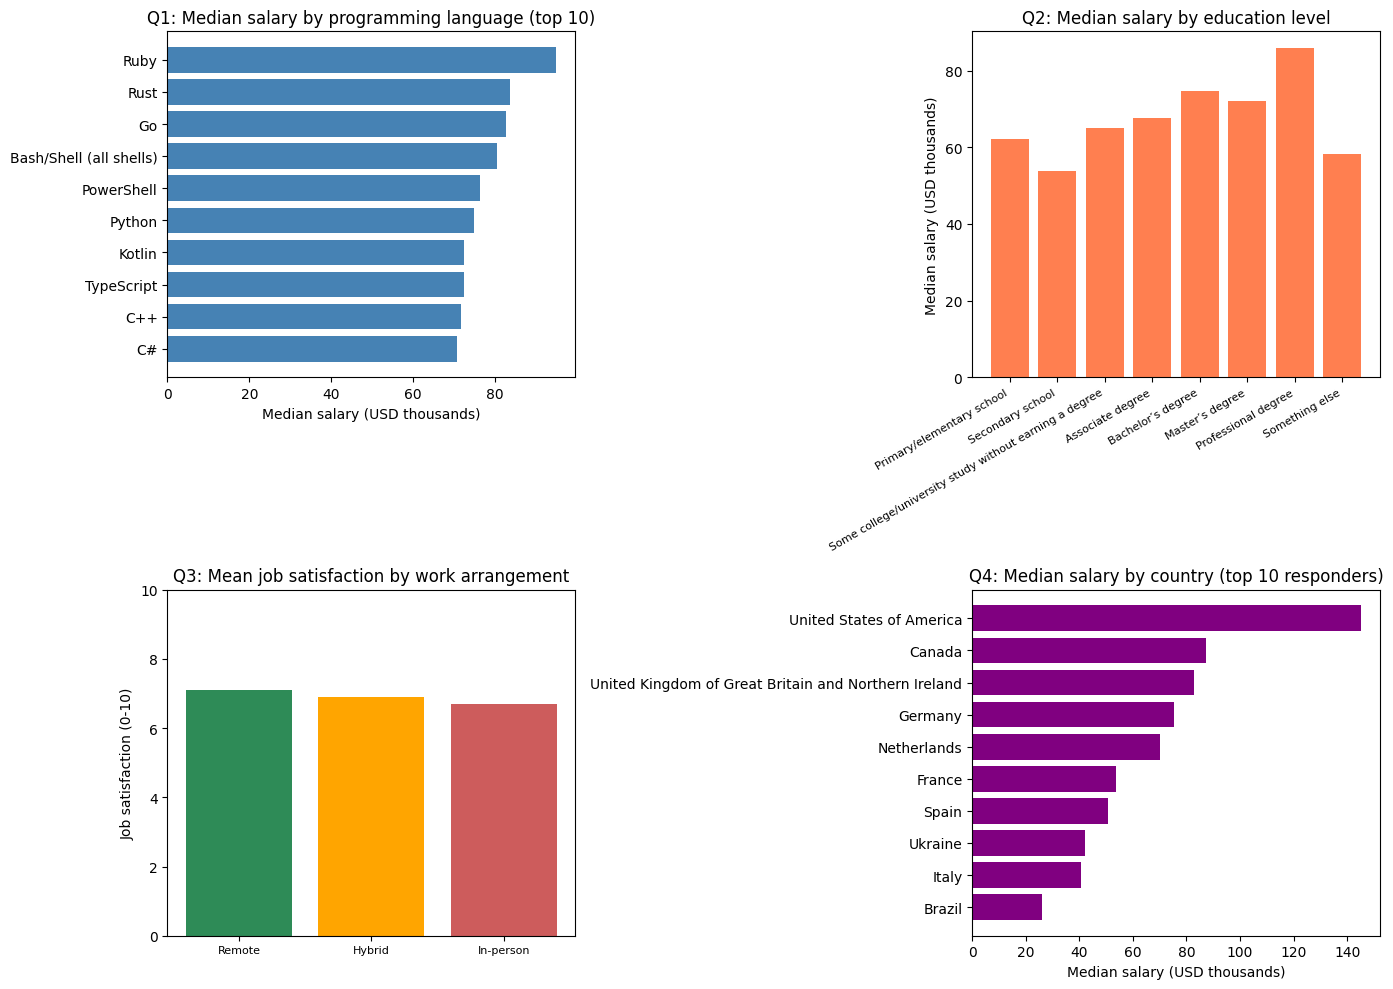

In [18]:
create_four_panel_visualization(
    language_salaries,
    education_salaries,
    work_mode_satisfaction,
    country_salaries,
)
Image("salary_analysis.png")

## CRISP-DM Stage 6 — Deployment

The findings are communicated to a non-technical audience in two places:

* **Blog post:** *What Really Drives Developer Salaries in 2024?* (`index.md`, published via GitHub Pages)
* **Repository README** with motivation, library list, file descriptions and acknowledgements

### Key takeaways

1. **Location dominates pay** — ~57% of model importance; US median \$145k vs India \$21k.
2. **Experience beats credentials** — r = 0.38 with salary, and Bachelor's holders out-earn Master's holders at the median.
3. **Niche languages carry a premium** — Ruby, Rust and Go top the charts; ubiquitous Python sits mid-pack.
4. **Remote workers are the most satisfied** (7.1/10 vs 6.7 in-person), and satisfaction is almost uncorrelated with salary (r ≈ 0.07).
5. **Half of salary variance is predictable** from seven profile facts (R² = 0.53).

**Acknowledgements:** StackOverflow for the public survey data (<https://survey.stackoverflow.co/>), and the open-source pandas / scikit-learn / matplotlib communities.